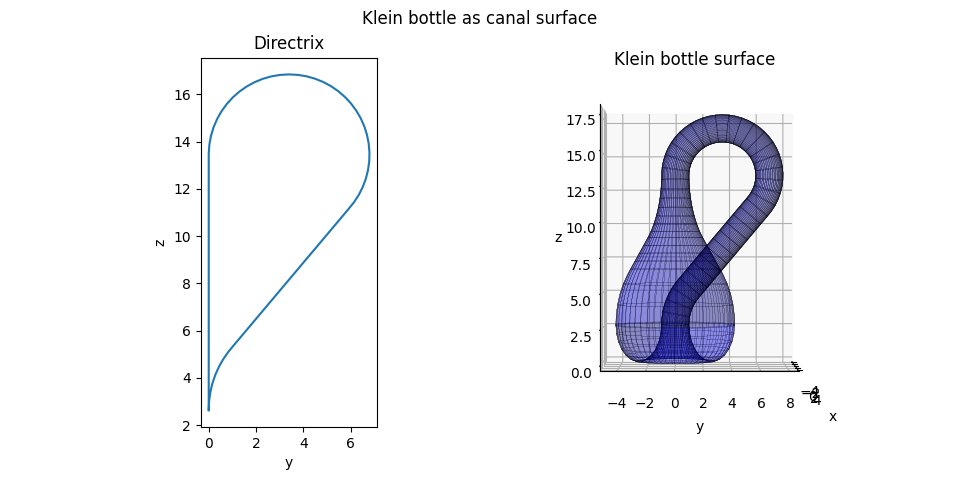

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
%matplotlib ipympl


#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
theta = .7
phi = .45
w = 8.6

h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = np.sqrt((w/2)*((w/2)-p)/2)
c = (h*np.sin(phi)+p*np.cos(phi)-(w/2))/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),d+h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,(w/2)*np.cos(phi),d+(w/2)*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

# Set up a figure and axes
fig = plt.figure(figsize=plt.figaspect(.5))
fig.suptitle('Klein bottle as canal surface')

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax1.set_title('Directrix')
ax2.set_title('Surface')

t = np.array([
    0,
    d, 
    (w/2)*np.sin(phi)+d, 
    h-c*np.sin(phi)+d, 
    h+d, 
    h+d+a*(np.pi+theta), 
    h+d+a*(np.pi+theta)+magPQ, 
    h+d+a*(np.pi+theta)+magPQ+b*theta
])

u = np.linspace(0, h+d+a*(np.pi+theta)+magPQ+b*theta, 100)

ut = [0]*(len(t)-1)

for j in range(len(t)-1):
    ut[j] = int(np.max(np.argwhere(u<t[j+1])))+1

usplit = np.split(u,ut)
d_index = int(np.max(np.argwhere(u<=d)))
ubase = usplit[0]
urest = u[d_index:]

#Plot base (not canal)
u = np.linspace(0,np.pi,2*d_index)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = (((w/2)+p)/2-(((w/2)-p)/2)*np.cos(u))*np.cos(v)
y = (((w/2)+p)/2-(((w/2)-p)/2)*np.cos(u))*np.sin(v)
z = d-d*np.sin(u)
ax2.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)

#Rest of bottle
u = urest
l = len(u)
gamma = np.zeros((3,l))
T = np.zeros((3,l))
N = np.zeros((3,l))
B = np.zeros((3,l))
r = np.zeros(l)
rdot = np.zeros(l)

for j,u in enumerate(u):
    if u < t[4]:
        #Diretrix
        gamma[:,j] = (0,0,u)
        #ON frame
        T[:,j] = (0,0,1)
        N[:,j] = (0,1,0)
        B[:,j] = (1,0,0)
        #Radius function
        if u <= t[2]:
            r[j] = np.sqrt((w/2)**2-(u-d)**2)
            rdot[j] = -(u-d)/np.sqrt((w/2)**2-(u-d)**2)
        elif t[2] < u <= t[3]:
            r[j] = (w/2)/np.cos(phi)-(u-d)*np.tan(phi)
            rdot[j] = -np.tan(phi)
        elif t[3] < u <= t[4]:
            r[j] = p+c-np.sqrt(c**2-(u-t[4])**2)
            rdot[j] = (u-t[4])/np.sqrt(c**2-(u-t[4])**2)
    elif u >= t[4]:
        #Handle
        #Radius function
        r[j] = p
        rdot[j] = 0            
        if u <= t[5]:
            #Directrix
            gamma[:,j] = (0, a*(1+np.cos(np.pi-(u-t[4])/a)), d+h+a*np.sin(np.pi-(u-t[4])/a))
            #ON frame
            T[:,j] = (0,np.sin(np.pi-(u-t[4])/a),-np.cos(np.pi-(u-t[4])/a))
            N[:,j] = (0,-np.cos(np.pi-(u-t[4])/a),-np.sin(np.pi-(u-t[4])/a))
            B[:,j] = (1,0,0)
        elif t[5] < u <= t[6]:
            #Directrix
            gamma[:,j] = ((u-t[5])/magPQ)*Q + (1-(u-t[5])/magPQ)*P
            #ON frame
            T[:,j] = (0,PQhat[1],PQhat[2])
            N[:,j] = (0,PQhat[2],-PQhat[1])
            B[:,j] = (1,0,0)
        elif t[6] < u <= t[7]:
            #Directrix
            gamma[:,j] = (0, b+b*np.cos(np.pi-theta+(u-t[6])/b), d+b*np.sin(np.pi-theta+(u-t[6])/b))
            #ON frame
            T[:,j] = (0,-np.sin(np.pi-theta+(u-t[6])/b),np.cos(np.pi-theta+(u-t[6])/b))
            N[:,j] = (0,np.cos(np.pi-theta+(u-t[6])/b),np.sin(np.pi-theta+(u-t[6])/b))
            B[:,j] = (1,0,0)

#Directrix plot
y = gamma[1]
z = gamma[2]
ax1.plot(y, z)

#Plot canal surface
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax2.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)

ax2.set_title('Klein bottle surface')

# Axis labels
ax1.set_xlabel('y')
ax1.set_ylabel('z')
#ax1.set_xlim(-.1*2*a,1.1*2*a)
#ax1.set_ylim(0,1.1*(h+d+a))

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax2.view_init(elev=0, azim=0, roll=0)

plt.show()

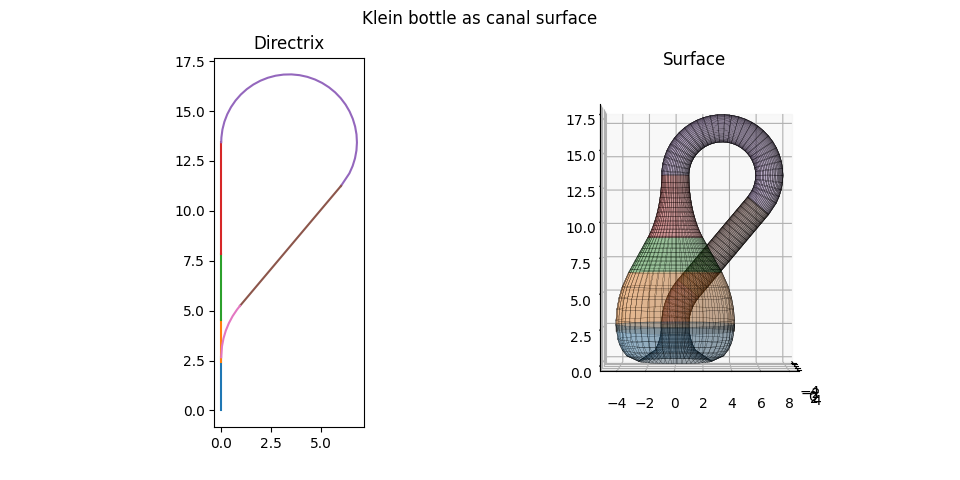

In [27]:

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
%matplotlib ipympl


#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
theta = .7
phi = .45
w = 8.6
e = w/2
h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = np.sqrt((w/2)*((w/2)-p)/2)
c = (h*np.sin(phi)+p*np.cos(phi)-(w/2))/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),d+h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,(w/2)*np.cos(phi),d+(w/2)*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])


t = np.array([
    0,
    d, 
    (w/2)*np.sin(phi)+d, 
    h-c*np.sin(phi)+d, 
    h+d, 
    h+d+a*(np.pi+theta), 
    h+d+a*(np.pi+theta)+magPQ, 
    h+d+a*(np.pi+theta)+magPQ+b*theta,
    h+2*d+a*(np.pi+theta)+magPQ+b*theta
])

u = np.linspace(0, np.max(t), 100)

ut = [0]*(len(t)-1)

for j in range(len(t)-1):
    ut[j] = int(np.max(np.argwhere(u<t[j+1])))

usplit = [u[:ut[0]],
          u[ut[0]:ut[1]+1],
          u[ut[1]:ut[2]+1],
          u[ut[2]:ut[3]+1],
          u[ut[3]:ut[4]+1],
          u[ut[4]:ut[5]+1],
          u[ut[5]:ut[6]+1],
          u[ut[6]:ut[7]+1]]

for j in range(len(ut)): #to remove annoying gaps
    l=len(usplit[j])
    usplit[j][l-1] = t[j+1]

# Set up a figure and axes
fig = plt.figure(figsize=plt.figaspect(.5))
fig.suptitle('Klein bottle as canal surface')

ax2 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2, projection='3d')

ax2.set_title('Directrix')
ax1.set_title('Surface')

#Base 1
#Not canal
u = usplit[0]
r = (p+e)/2+((e-p)/2)*np.sqrt(1-((u-d)/d)**2)
gamma = (0,0,u)
T = (0,0,1)
N = (0,1,0)
B = (1,0,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(0*gamma[2],gamma[2])

#Bottle canal 1
u = usplit[1]
r = np.sqrt((w/2)**2-(u-d)**2)
rdot = -(u-d)/np.sqrt((w/2)**2-(u-d)**2)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(0*gamma[2],gamma[2])

#Bottle canal 2
u = usplit[2]
r = (w/2)/np.cos(phi)-(u-d)*np.tan(phi)
rdot = -np.tan(phi)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(0*gamma[2],gamma[2])


#Bottle canal 3
u = usplit[3]
r = p+c-np.sqrt(c**2-(u-t[4])**2)
rdot = (u-t[4])/np.sqrt(c**2-(u-t[4])**2)
gamma = (0,0,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(0*gamma[2],gamma[2])

#Handle 4
u = usplit[4]
r = p
rdot = 0
gamma = (0, a*(1+np.cos(np.pi-(u-t[4])/a)), d+h+a*np.sin(np.pi-(u-t[4])/a))
T = (0,np.sin(np.pi-(u-t[4])/a),-np.cos(np.pi-(u-t[4])/a))
N = (0,-np.cos(np.pi-(u-t[4])/a),-np.sin(np.pi-(u-t[4])/a))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(gamma[1],gamma[2])

#Handle 5
u = usplit[5]
gamma = (0,((u-t[5])/magPQ)*Q[1] + (1-(u-t[5])/magPQ)*P[1],((u-t[5])/magPQ)*Q[2] + (1-(u-t[5])/magPQ)*P[2])
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(gamma[1],gamma[2])

#Handle 6
u = usplit[6]
gamma = (0, b+b*np.cos(np.pi-theta+(u-t[6])/b), d+b*np.sin(np.pi-theta+(u-t[6])/b))
T = (0,-np.sin(np.pi-theta+(u-t[6])/b),np.cos(np.pi-theta+(u-t[6])/b))
N = (0,np.cos(np.pi-theta+(u-t[6])/b),np.sin(np.pi-theta+(u-t[6])/b))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(gamma[1],gamma[2])

#Base 7
u = usplit[7]
r = (p+e)/2-((e-p)/2)*np.sqrt(1-((u-u[0])/d)**2)
gamma = (0,0,h+2*d+a*(np.pi+theta)+magPQ+b*theta-u)
T = (0,0,-1)
N = (0,-1,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))

ax1.plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
ax2.plot(0*u,h+2*d+a*(np.pi+theta)+magPQ+b*theta-u)

ax1.set_aspect('equal')
ax1.view_init(elev=0, azim=0, roll=0)

ax2.set_aspect('equal')

plt.show()



In [ ]:
#translate/truncate u so 0<=u<=esin(phi) (for formula convenience)
t2_index = int(np.max(np.argwhere(urest<=t[2])))
u=urest[:t2_index]-d
u=u[int(np.min(np.argwhere(u>=0))):]
ustep=u[1]-u[0]
e=w/2
#line element in u direction
E=4*(e**2-u**2)/(e**2-2*u**2)
ds=np.sqrt(E)*ustep
print('u =',u)
print('E =',E)
print('ds =',ds)
#surface
r = np.sqrt(e**2-u**2)
rdot = -u/np.sqrt(e**2-u**2)
gamma = (0,0,u)
T = (0,0,1)
N = (0,1,0)
B = (1,0,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

fig = plt.figure(figsize = (7,8), label = ' ')
ax = plt.axes(projection='3d')

ax.plot_surface(x, y, z+d, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)

ax.set_aspect('equal')
ax.view_init(elev=0, azim=0, roll=0)


In [ ]:
import numpy as np

#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
theta = .7
phi = .45
w = 8.6

h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = np.sqrt((w/2)*((w/2)-p)/2)
c = (h*np.sin(phi)+p*np.cos(phi)-(w/2))/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),d+h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,(w/2)*np.cos(phi),d+(w/2)*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

t = np.array([
    0,
    d, 
    (w/2)*np.sin(phi)+d, 
    h-c*np.sin(phi)+d, 
    h+d, 
    h+d+a*(np.pi+theta), 
    h+d+a*(np.pi+theta)+magPQ, 
    h+d+a*(np.pi+theta)+magPQ+b*theta
])

u = np.linspace(0, h+d+a*(np.pi+theta)+magPQ+b*theta, 100)
ut = [0]*(len(t)-1)

for j in range(len(t)-1):
    ut[j] = int(np.max(np.argwhere(u<t[j+1])))+1

usplit = np.split(u,ut)

print('t =',t)
print('u =',u)
print('ut =',ut)
print('usplit =',usplit)
#upart = u
#for k in range(1,len(t)):
#    upart[k] = np.where(u<=t[k],u,u)
#    upart[k] = np.where(upart[k]>t[k-1],u,u)
#    print('upart[',k,'] =',upart[k])